In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import time
import pickle
import os
import subprocess
import matplotlib.pyplot as plt
from scipy.stats import norm

from e_1_run_cvae import compare_prices
from e_2_CVAE import *


# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

B = 0.8 # down-and-out must B < S0 and B < K
opt_type = 'call' # call or put
barr_type = 'van' # van or barr
model_type = 'bs' # hes or bs

if not((B < S0) & (B < K)):
    raise ValueError("down-and-out : B should be smaller than S0 and K")

if not(opt_type == 'call' or  opt_type == 'put'):
    raise ValueError("option_type must be 'call' or 'put'")

if not(barr_type == 'van' or  barr_type == 'barr'):
    raise ValueError("barr_type must be 'van' or 'barr'")

if not(model_type == 'hes' or  model_type == 'bs'):
    raise ValueError("model_type must be 'hes' or 'bs'")

if not(torch.cuda.is_available()):
    raise ValueError("CUDA is not available")
device = torch.device("cuda")

if model_type == 'hes':
    if barr_type == 'barr':
        if opt_type == 'call':
            bench_price = 0.115733
        else: # put
            bench_price = 0.005170
    else: # van
        if opt_type == 'call':
            bench_price = 0.124491
        else: # put
            bench_price = 0.080488

elif model_type == 'bs':
    if barr_type == 'barr':
        if opt_type == 'call':
            bench_price = 0.123493
        else: # put
            bench_price = 0.009535
    else: # van
        if opt_type == 'call':
            bench_price = 0.129944
        else: # put
            bench_price = 0.085942

In [ ]:
# CVAE DDP training settings
dim_z       = 8 # 12
hidden_dims = [128, 128, 64] # [128, 128, 64], [256, 256, 128], [512, 512, 256]
batch_size  = 4096
lr          = 1e-3 # 3e-4, 5e-4
beta        = 1.0
warmup_chunks = None
bn_chunks   = 20 # None or num
use_bn      = True if bn_chunks is not None else False
num_chunks = 5
resume_path = None
save_path = f"cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size*7}_{bn_chunks}_{warmup_chunks}_chunk.pt"

n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

gpu_ids = "0,1,2,3,4,5,6" # 7 GPU problem
nproc = len(gpu_ids.split(","))

hidden_dims_arg = ",".join(map(str, hidden_dims))


# inference for comparing with MC result

In [ ]:
cvae_save_path = f"cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size*7}_{bn_chunks}_{warmup_chunks}_chunk20.pt" # = save_path

cvae_result_path = f"cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size*7}_{bn_chunks}_{warmup_chunks}_chunk20.pkl"

ckpt = torch.load(cvae_save_path, map_location=device, weights_only=False)

cvae = CVAE(
    dim_x=ckpt["dim_x"],
    dim_eta=ckpt["dim_eta"],
    dim_z=ckpt["dim_z"],
    hidden_dims=ckpt["hidden_dims"],
    use_bn=ckpt.get("use_bn", False),
).to(device)

state_dict = ckpt["model_state"]
if any(k.startswith("module.") for k in state_dict):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

cvae.load_state_dict(state_dict)
cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

n_list = [1000, 10000, 100000]
n_repeats = 50
results = {n: [] for n in n_list}


for n in n_list:
    for _ in range(n_repeats):
        if barr_type == "barr":
            price = cvae.price_barrier(eta_t, B, K, r, T, opt_type, n)
        else:
            price = cvae.price_vanilla(eta_t, K, r, T, opt_type, n)
        results[n].append(price)

with open(cvae_result_path, "wb") as f:
    pickle.dump(results, f)

CVAE
n=  1000 | mean=0.12329833 | 95% CI=±0.01043970 | error=-5.11%
n= 10000 | mean=0.12399877 | 95% CI=±0.00411200 | error=-4.58%
n=100000 | mean=0.12396854 | 95% CI=±0.00123737 | error=-4.60%


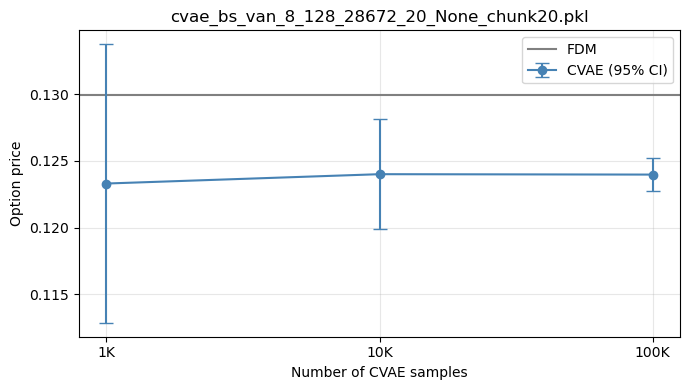

In [ ]:
# 공용 그래프: CVAE inference 결과만 표시
n_list = [1000, 10000, 100000]
cvae_result_path = f"cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size*7}_{bn_chunks}_{warmup_chunks}_chunk20.pkl"

with open(cvae_result_path, "rb") as f:
    results = pickle.load(f)

means = np.array([np.mean(results[n]) for n in n_list])
stds = np.array([np.std(results[n]) for n in n_list])
ci = 1.96 * stds

print("CVAE")
for n, mean, err in zip(n_list, means, ci):
    rel_err = (mean - bench_price) / (bench_price + 1e-12) * 100
    print(f"n={n:6d} | mean={mean:.8f} | 95% CI=±{err:.8f} | error={rel_err:+.2f}%")

plt.figure(figsize=(7, 4))
plt.axhline(bench_price, color="gray", linewidth=1.5, label="FDM")
plt.errorbar(
    range(len(n_list)), means,
    yerr=ci, fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
)
plt.xticks(range(len(n_list)), ["1K", "10K", "100K"])
plt.xlabel("Number of CVAE samples")
plt.ylabel("Option price")
plt.title(f"{cvae_result_path}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
